In [9]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [10]:
data = load_breast_cancer()
X = pd.DataFrame(data.data , columns = data.feature_names)
y = data.target

X_train, X_test , y_train , y_test = train_test_split(X,y,test_size = 0.3 , random_state = 42)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

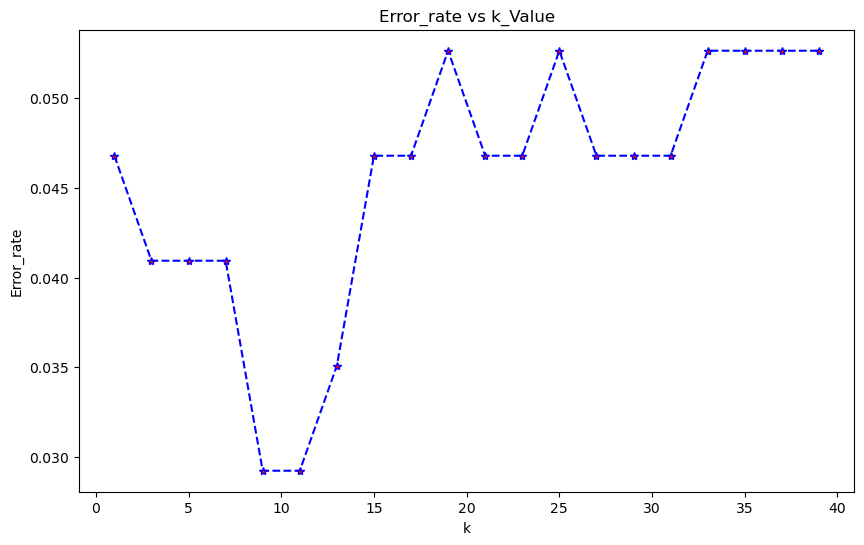

In [15]:
error_rate = []

for i in range(1,40,2):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train_scaled , y_train)
    pred_i = knn.predict(X_test_scaled)

    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize = (10,6))
plt.plot(range(1,40,2) , error_rate , color = 'blue' , linestyle = 'dashed' , marker ='*' , markerfacecolor ='red')
plt.title('Error_rate vs k_Value')
plt.xlabel('k')
plt.ylabel('Error_rate')
plt.show()

In [24]:
final_knn = KNeighborsClassifier(n_neighbors = 10)
final_knn.fit(X_train_scaled , y_train)
predictions = final_knn.predict(X_test_scaled)
print("---Confusion Matrix---")
print(confusion_matrix(y_test,predictions)) 
print("\n --- Classifications_report --- \n")
print(classification_report(y_test,predictions))
print(f"Ovrall accuracy :{accuracy_score(y_test , predictions):.4f}")

---Confusion Matrix---
[[ 60   3]
 [  2 106]]

 --- Classifications_report --- 

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

Ovrall accuracy :0.9708
